# Cross-Path Allen-13 Intersection vs Best-Single-Path — decisive real-text test

**Artifact `art_0AIWMhwc1pJM` (iter-4).** Does the cross-path full-PC **INTERSECTION** of
disjunctive LLM Allen-interval reads narrow deduction-required temporal queries strictly
**beyond the best single path's composition**, using the **full Allen interval algebra (13
relations)** on frozen real temporal gold graphs (TDDMan)?

**Verdict: SCOPE-BOUNDARY.** The cross-path coding mechanism is *structurally present in the
gold* (a-priori gate GO, N=125) and *works on a synthetic Allen channel* (positive control:
intersection beats best-single at reader-recall 0.95), but **cannot realize on real text**:
LLM Allen reads of constituent edges are near-universe / underdetermined, so the composition
of near-universe sets stays at the universe and the realized bite is zero.

This is the **precision/recall impossibility**: high-recall disjunctive reads are *sound but
near-universe* (no bite); forcing a single tight relation (the `raw` baseline) is tight but
only ~3% correct (*unsound*). Text underdetermines interval endpoints, so no reader operating
point yields tight-AND-sound Allen reads.

---
### What this demo runs (all `$0`, no API keys)
1. **Allen-13 algebra + QCN path-consistency closure engine** (`engine.py`) — the symbolic
   reasoner (the running logic interpreter).
2. **Synthetic Allen positive control** (`synth_allen.py`) — consistent-by-construction QCNs +
   a noisy reader channel; confirms the comparison code detects a true *intersection >
   best-single* effect when reads are sound.
3. **Real-text replay** — the cached TDDMan LLM-read outcomes (`mini_demo_data.json`) are
   scored with the *same matched-coverage paired-bootstrap leaderboard* (`method.py`),
   reproducing the decisive negative.

> The full pipeline's LLM read step (gemini-3.1-flash-lite + deepseek-v3.2) is **not** re-run
> here — its per-query outcomes are loaded from the cached demo subset, so the notebook runs
> offline in well under a minute.

In [1]:
# --- Install dependencies (Colab + local Jupyter compatible) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab -> install ONLY locally (behind the guard),
# at Colab's exact versions, so the local env matches Colab and the C-extensions aren't
# corrupted on Colab. The engine itself is pure-stdlib; numpy drives the synthetic control
# and the bootstrap, matplotlib draws the figures.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors engine.py / synth_allen.py / method.py) ---
from __future__ import annotations
import json, os, itertools, types
from collections import deque, defaultdict
from typing import Iterable
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Data loading: GitHub raw URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-4/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
examples = data["examples"]
print(f"loaded {len(examples)} cached {data.get('dataset_name','tddman')} query examples")
print("recorded verdict      :", meta["headline_findings"]["verdict"])
print("recorded gate_decision:", meta["headline_findings"]["gate_decision"])
print("recorded headline N   :", meta["headline_findings"]["combined_headline_eligible_N"])

loaded 80 cached tddman query examples
recorded verdict      : SCOPE-BOUNDARY
recorded gate_decision: GO
recorded headline N   : 125


## Configuration

All tunable parameters live here. The synthetic-control sample (`SYNTH_N_NET`) and the bootstrap
resample count (`BOOT_B`) are the only knobs that affect runtime. The whole `$0` compute is only
~2 seconds even at the **original full-run values** (`SYNTH_N_NET=500`, `BOOT_B=2000`), so we use
them directly here; the comments show the smaller fast-iteration values if you want to scale down.

In [5]:
# ---- Synthetic Allen positive control (synth_allen.run_control) ----
# The ORIGINAL full-run values fit the demo runtime budget (compute ~2s), so we use them
# directly. For faster iteration, drop SYNTH_N_NET to ~120 and BOOT_B to ~500 (the smallest
# values that still reproduce the qualitative result).
SYNTH_N_NET    = 500     # networks per recall cell  (method.py full run: 500; fast demo: 120)
SYNTH_N_EVENTS = 6       # events per random QCN (-> 4 disjoint via-paths); original: 6
SYNTH_RECALLS  = (0.95, 0.85, 0.70)   # reader-channel soundness sweep (original: same)

# ---- Statistics (method.py module constants) ----
SEED   = 20260617        # method.py SEED (verbatim)
ALPHA  = 0.05            # method.py ALPHA (verbatim)
BOOT_B = 2000            # bootstrap resamples       (method.py full run: 2000; fast demo: 500)
ALLEN_GATE = 0.85        # per-edge Allen recall gate (method.py)

print("config:", dict(SYNTH_N_NET=SYNTH_N_NET, SYNTH_RECALLS=SYNTH_RECALLS, BOOT_B=BOOT_B))

config: {'SYNTH_N_NET': 500, 'SYNTH_RECALLS': (0.95, 0.85, 0.7), 'BOOT_B': 2000}


## Section A — Allen-13 algebra + QCN path-consistency closure engine (`engine.py`)

The symbolic core, copied **verbatim** from `engine.py`. It builds two qualitative calculi
programmatically (no external table files):

* **POINT** — convex point algebra over event start-points `{<,=,>}`.
* **ALLEN** — the full Allen interval algebra (**13 base relations**). The base×base
  composition table is generated by the *endpoint method* (enumerate weak orders of the six
  interval endpoints) and the result is what makes cross-path intersection *possible*: unlike
  iter-3's coarse point projection (which collapsed `{before,meets}` and made `full==naive`),
  the Allen algebra keeps disjunctive sets rich enough to tighten.

Closure operators: `pc2_full` (Mackworth PC-2 worklist closure to fixpoint = OUR METHOD) and
`naive_single_pass` (one pass of length-2 path intersections at the query edge = baseline).

In [6]:
from __future__ import annotations

import itertools
from collections import deque
from typing import Iterable

# ----------------------------------------------------------------------------------
# Allen-13 base relations (qualreas-compatible symbols) and their endpoint geometry.
# Interval X = (Xs, Xe) with Xs < Xe. relation(X, Y) defined on (Xs, Xe, Ys, Ye).
# ----------------------------------------------------------------------------------
ALLEN_BASE = ["B", "BI", "D", "DI", "O", "OI", "M", "MI", "S", "SI", "F", "FI", "E"]
ALLEN_CONVERSE = {"B": "BI", "BI": "B", "D": "DI", "DI": "D", "O": "OI", "OI": "O",
                  "M": "MI", "MI": "M", "S": "SI", "SI": "S", "F": "FI", "FI": "F", "E": "E"}


def _allen_rel(xs: int, xe: int, ys: int, ye: int) -> str | None:
    """Atomic Allen relation of interval X=(xs,xe) to Y=(ys,ye) from endpoint ranks.

    Assumes proper intervals (xs<xe, ys<ye). Returns one of the 13 base symbols.
    """
    if not (xs < xe and ys < ye):
        return None
    if xs == ys and xe == ye:
        return "E"
    if xe < ys:
        return "B"
    if ye < xs:
        return "BI"
    if xe == ys:
        return "M"
    if ye == xs:
        return "MI"
    if xs == ys:
        return "S" if xe < ye else "SI"
    if xe == ye:
        return "F" if xs > ys else "FI"
    if xs < ys and ye < xe:
        return "DI"
    if ys < xs and xe < ye:
        return "D"
    if xs < ys < xe < ye:
        return "O"
    if ys < xs < ye < xe:
        return "OI"
    return None  # unreachable for proper intervals


def _build_allen_compose() -> dict[tuple[str, str], frozenset]:
    """Generate the Allen base x base composition table via endpoint enumeration.

    Enumerate every rank assignment of the 6 endpoints (As,Ae,Bs,Be,Cs,Ce) in 0..5
    (ties allowed; only relative order matters). For each that yields proper intervals,
    record comp[r(A,B)][r(B,C)] |= {r(A,C)}.
    """
    comp: dict[tuple[str, str], set] = {(a, b): set() for a in ALLEN_BASE for b in ALLEN_BASE}
    for asg in itertools.product(range(6), repeat=6):
        As, Ae, Bs, Be, Cs, Ce = asg
        if not (As < Ae and Bs < Be and Cs < Ce):
            continue
        rab = _allen_rel(As, Ae, Bs, Be)
        rbc = _allen_rel(Bs, Be, Cs, Ce)
        rac = _allen_rel(As, Ae, Cs, Ce)
        if rab is None or rbc is None or rac is None:
            continue
        comp[(rab, rbc)].add(rac)
    return {k: frozenset(v) for k, v in comp.items()}


# ----------------------------------------------------------------------------------
# Point algebra over start-points.
# ----------------------------------------------------------------------------------
POINT_BASE = ["<", "=", ">"]
POINT_CONVERSE = {"<": ">", "=": "=", ">": "<"}
# GQR point.comp (verified): = is identity; <o<={<}; >o>={>}; <o>=>o<=universal.
POINT_COMPOSE = {
    ("=", "="): frozenset({"="}),
    ("<", "="): frozenset({"<"}), ("=", "<"): frozenset({"<"}),
    (">", "="): frozenset({">"}), ("=", ">"): frozenset({">"}),
    ("<", "<"): frozenset({"<"}),
    (">", ">"): frozenset({">"}),
    ("<", ">"): frozenset({"<", "=", ">"}),
    (">", "<"): frozenset({"<", "=", ">"}),
}
POINT_NONCONVEX = frozenset({"<", ">"})  # the only non-convex point relation (`!=`)


class Algebra:
    """A qualitative calculus with relation sets stored as frozensets of base symbols."""

    def __init__(self, name: str, base: list[str], converse: dict[str, str],
                 compose_bb: dict[tuple[str, str], frozenset], identity: frozenset,
                 convex_widen: frozenset | None = None):
        self.name = name
        self.base = list(base)
        self.universe = frozenset(base)
        self.empty = frozenset()
        self.identity = frozenset(identity)
        self._conv = dict(converse)
        self._comp = dict(compose_bb)
        # `convex_widen` (point algebra only): the unique non-convex relation that must
        # be widened to the universal set to keep PC complete. None => no widening.
        self._nonconvex = convex_widen

    # ---- set ops -----------------------------------------------------------------
    def converse(self, s: frozenset) -> frozenset:
        return frozenset(self._conv[r] for r in s)

    def compose(self, a: frozenset, b: frozenset) -> frozenset:
        if not a or not b:
            return self.empty
        out: set = set()
        for x in a:
            for y in b:
                out |= self._comp[(x, y)]
        return frozenset(out)

    def is_nonconvex(self, s: frozenset) -> bool:
        return self._nonconvex is not None and s == self._nonconvex

    def widen(self, s: frozenset) -> tuple[frozenset, bool]:
        """Return (possibly-widened set, fired?). Widening only happens for the
        unique non-convex relation of a convex algebra (point: `{<,>}` -> universe)."""
        if self._nonconvex is not None and s == self._nonconvex:
            return self.universe, True
        return s, False

    def label(self, s: frozenset) -> str:
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(r for r in self.base if r in s)


def build_point_algebra() -> Algebra:
    return Algebra("POINT", POINT_BASE, POINT_CONVERSE, POINT_COMPOSE,
                   frozenset({"="}), convex_widen=POINT_NONCONVEX)


def build_allen_algebra() -> Algebra:
    return Algebra("ALLEN", ALLEN_BASE, ALLEN_CONVERSE, _build_allen_compose(),
                   frozenset({"E"}), convex_widen=None)


# ----------------------------------------------------------------------------------
# Triangle closure (frontier metric primitive)
# ----------------------------------------------------------------------------------
def close_triangle(alg: Algebra, ab: frozenset, bc: frozenset, ac: frozenset):
    """Length-2 path A-B-C narrowing the query edge A-C.

    path  = compose(ab, bc)                    (with convex widening applied + counted)
    inter = path & ac                          (widening applied + counted)
    Returns dict: path, inter, empty(collapse), singleton, n_widen.
    """
    n_widen = 0
    path = alg.compose(ab, bc)
    path, w = alg.widen(path)
    n_widen += int(w)
    inter = path & ac
    inter, w = alg.widen(inter)
    n_widen += int(w)
    return {
        "path": path,
        "inter": inter,
        "empty": len(inter) == 0,
        "singleton": len(inter) == 1,
        "n_widen": n_widen,
    }


# ----------------------------------------------------------------------------------
# Full QCN + closure variants (reused by whole-document consistency checks)
# ----------------------------------------------------------------------------------
class QCN:
    """Constraint network: dense node list, edges = relation-set frozensets.

    Missing edge => universe. Invariants on set_edge: M[j][i]==converse(M[i][j]),
    M[i][i]==identity.
    """

    def __init__(self, alg: Algebra, nodes: list):
        self.alg = alg
        self.nodes = list(nodes)
        self.n = len(self.nodes)
        self.index = {nd: i for i, nd in enumerate(self.nodes)}
        U = alg.universe
        self.M = [[U] * self.n for _ in range(self.n)]
        for i in range(self.n):
            self.M[i][i] = alg.identity
        self.nbrs: list[set] = [set() for _ in range(self.n)]

    def set_edge(self, i: int, j: int, s: frozenset) -> None:
        if i == j:
            return
        self.M[i][j] = s
        self.M[j][i] = self.alg.converse(s)
        if s != self.alg.universe:
            self.nbrs[i].add(j); self.nbrs[j].add(i)
        else:
            self.nbrs[i].discard(j); self.nbrs[j].discard(i)

    def get(self, i: int, j: int) -> frozenset:
        return self.M[i][j]

    def known_edges(self) -> list[tuple[int, int]]:
        U = self.alg.universe
        return [(i, j) for i in range(self.n) for j in range(i + 1, self.n) if self.M[i][j] != U]


def pc2_full(qcn: QCN):
    """OUR METHOD: Mackworth PC-2 worklist closure to fixpoint.

    Returns (consistent: bool, n_fired). Empty edge => inconsistent (Mode-B certificate).
    Convex widening (point algebra) applied to every refined edge and absorbed silently
    (it can only enlarge a set, never empties it).
    """
    alg = qcn.alg
    U = alg.universe
    M = qcn.M
    nbrs = qcn.nbrs
    Q = deque()
    inq = set()
    for (i, j) in qcn.known_edges():
        Q.append((i, j)); inq.add((i, j))
        Q.append((j, i)); inq.add((j, i))
    n_fired = 0

    def enqueue(a, b):
        if (a, b) not in inq:
            inq.add((a, b)); Q.append((a, b))

    while Q:
        i, j = Q.popleft(); inq.discard((i, j))
        rij = M[i][j]
        if rij == U:
            continue
        for k in list(nbrs[j]):
            if k == i:
                continue
            comp = alg.compose(rij, M[j][k])
            new = M[i][k] & comp
            new, _ = alg.widen(new)
            if new != M[i][k]:
                if not new:
                    return False, n_fired
                M[i][k] = new; M[k][i] = alg.converse(new)
                nbrs[i].add(k); nbrs[k].add(i)
                n_fired += 1
                enqueue(i, k); enqueue(k, i)
        for k in list(nbrs[i]):
            if k == j:
                continue
            comp = alg.compose(M[k][i], rij)
            new = M[k][j] & comp
            new, _ = alg.widen(new)
            if new != M[k][j]:
                if not new:
                    return False, n_fired
                M[k][j] = new; M[j][k] = alg.converse(new)
                nbrs[k].add(j); nbrs[j].add(k)
                n_fired += 1
                enqueue(k, j); enqueue(j, k)
    return True, n_fired


def naive_single_pass(qcn: QCN, u: int, v: int) -> frozenset:
    """BASELINE: single pass of length-2 path compositions at the query edge (u,v).

    Intersects compose(R(u,w), R(w,v)) over intermediate w with informative u-w & w-v.
    NO fixpoint, NO re-propagation.
    """
    alg = qcn.alg
    U = alg.universe
    M = qcn.M
    R = U
    for w in qcn.nbrs[u]:
        if w in (u, v):
            continue
        if M[w][v] != U:
            R = R & alg.compose(M[u][w], M[w][v])
            R, _ = alg.widen(R)
            if not R:
                return alg.empty
    return R

# --- notebook shim: expose the engine functions under an `engine.` namespace so the
# verbatim synth_allen.py code below (which calls engine.QCN, engine.pc2_full, ...) runs
# unchanged in the flat notebook namespace ---
engine = types.SimpleNamespace(
    build_allen_algebra=build_allen_algebra, build_point_algebra=build_point_algebra,
    QCN=QCN, pc2_full=pc2_full, naive_single_pass=naive_single_pass,
    close_triangle=close_triangle, _allen_rel=_allen_rel, Algebra=Algebra,
)

AL = build_allen_algebra()
print("ALLEN base:", AL.base, "| compose cells:", len(AL._comp))
print("ALLEN  B o B  =", sorted(AL.compose(frozenset({'B'}), frozenset({'B'}))))
print("ALLEN  D o DI =", sorted(AL.compose(frozenset({'D'}), frozenset({'DI'}))))

ALLEN base: ['B', 'BI', 'D', 'DI', 'O', 'OI', 'M', 'MI', 'S', 'SI', 'F', 'FI', 'E'] | compose cells: 169
ALLEN  B o B  = ['B']
ALLEN  D o DI = ['B', 'BI', 'D', 'DI', 'E', 'F', 'FI', 'M', 'MI', 'O', 'OI', 'S', 'SI']


## Section B — Synthetic Allen positive control (`synth_allen.py`)

Copied **verbatim** from `synth_allen.py`. Random *proper intervals* induce an exact atomic
Allen relation between every pair (a consistent-by-construction QCN). Each constituent edge is
then read through a **noisy channel** with an explicit recall knob `r`: with probability `r`
the read is *sound* (contains the truth, possibly widened); otherwise *unsound* (excludes it).

The same five-method comparison the real-text pipeline runs is applied. The positive-control
prediction: when reads are sound (`r ≈ 0.95`), the cross-path **intersection must resolve
strictly more query singletons correctly than the best single path** — proof that the
comparison code can detect a true effect.

In [7]:
AL = engine.build_allen_algebra()


def _atomic(intervals, a, b):
    (xs, xe), (ys, ye) = intervals[a], intervals[b]
    return engine._allen_rel(xs, xe, ys, ye)


def gen_network(n_events, rng):
    """Random proper intervals -> exact atomic Allen relation for every pair (consistent)."""
    pts = rng.integers(0, 40, size=(n_events, 2))
    intervals = []
    for s, e in pts:
        lo, hi = (int(s), int(e)) if s != e else (int(s), int(s) + 1)
        if lo > hi:
            lo, hi = hi, lo
        if lo == hi:
            hi += 1
        intervals.append((lo, hi))
    return intervals


def simulate_read(true_sym, r, rng, breadth=(0.45, 0.4, 0.15)):
    """Emit a relation SET for an edge whose atomic truth is true_sym. With prob r the read
    is SOUND (contains the truth, optionally widened); else UNSOUND (excludes truth)."""
    base = list(AL.base)
    if rng.random() < r:
        # sound: include the truth + (breadth) extra relations
        roll = rng.random()
        if roll < breadth[0]:
            return frozenset({true_sym})
        elif roll < breadth[0] + breadth[1]:
            extra = rng.choice([x for x in base if x != true_sym], size=1, replace=False)
            return frozenset({true_sym, *extra})
        else:
            k = int(rng.integers(2, 5))
            extra = rng.choice([x for x in base if x != true_sym],
                               size=min(k, len(base) - 1), replace=False)
            return frozenset({true_sym, *extra})
    else:
        # unsound: a random non-empty set NOT containing the truth
        pool = [x for x in base if x != true_sym]
        k = int(rng.integers(1, 3))
        return frozenset(rng.choice(pool, size=min(k, len(pool)), replace=False).tolist())


def run_one(n_events, r, rng):
    intervals = gen_network(n_events, rng)
    nodes = list(range(n_events))
    s, t = 0, 1
    vias = nodes[2:]
    true_q = _atomic(intervals, s, t)
    qcn = engine.QCN(AL, nodes)
    reads = {}
    confs = {}
    induced = [(s, w) for w in vias] + [(w, t) for w in vias]
    # include via-via edges for iteration
    for i in range(len(vias)):
        for j in range(i + 1, len(vias)):
            induced.append((vias[i], vias[j]))
    for (a, b) in induced:
        tr = _atomic(intervals, a, b)
        rd = simulate_read(tr, r, rng)
        reads[(a, b)] = rd
        confs[(a, b)] = float(min(1.0, max(0.0, rng.normal(0.7, 0.15))))
        qcn.set_edge(qcn.index[a], qcn.index[b], rd)
    qi, qj = qcn.index[s], qcn.index[t]
    path_conf = float(min(confs.values())) if confs else 0.0
    naive_set = engine.naive_single_pass(qcn, qi, qj)
    per_path = []
    for w in vias:
        per_path.append(AL.compose(reads[(s, w)], reads[(w, t)]))
    best = min(per_path, key=len) if per_path else AL.universe
    ok, _ = engine.pc2_full(qcn)
    inter = AL.empty if not ok else qcn.get(qi, qj)

    def rec(R):
        if not R:
            return {"answered": False, "correct": None, "conf": path_conf}
        if len(R) == 1:
            return {"answered": True, "correct": int(next(iter(R)) == true_q), "conf": path_conf}
        return {"answered": False, "correct": None, "conf": path_conf}
    return {"intersection": rec(inter), "best_single": rec(best), "naive": rec(naive_set),
            "bite": len(best) - len(inter), "singleton_resolved": int(len(inter) == 1)}


def run_control(n_net=600, n_events=6, r=0.95, seed=12345):
    rng = np.random.default_rng(seed)
    rows = {m: [] for m in ("intersection", "best_single", "naive")}
    bites, res = [], 0
    for _ in range(n_net):
        out = run_one(n_events, r, rng)
        for m in rows:
            rows[m].append(out[m])
        bites.append(out["bite"])
        res += out["singleton_resolved"]

    def cov_acc(recs):
        ans = [x for x in recs if x["answered"]]
        cov = len(ans) / len(recs) if recs else float("nan")
        acc = float(np.mean([x["correct"] for x in ans])) if ans else float("nan")
        return cov, acc
    out = {}
    for m in rows:
        cov, acc = cov_acc(rows[m])
        out[m] = {"coverage": cov, "selective_acc": acc}
    inter_cov = out["intersection"]["coverage"]
    best_cov = out["best_single"]["coverage"]
    return {"n_net": n_net, "n_events": n_events, "recall": r,
            "per_method": out, "mean_bite": float(np.mean(bites)),
            "intersection_resolves_more_than_best_single": bool(inter_cov > best_cov + 1e-9),
            "coverage_gain_intersection_vs_best": float(inter_cov - best_cov),
            "singleton_resolved_rate": res / n_net, "tag": "SYNTHETIC-ALLEN-CONTROL"}

### Run the synthetic control across the reader-recall sweep

`intersection_resolves_more_than_best_single` should flip to **True** at `recall = 0.95` (sound
reads) and be **False** at lower recall — exactly the recorded full-run behaviour.

In [8]:
synth = {f"recall_{int(r*100)}": run_control(n_net=SYNTH_N_NET, n_events=SYNTH_N_EVENTS,
                                                r=r, seed=SEED + int(r * 100))
         for r in SYNTH_RECALLS}

print(f"{'recall':>7} | {'inter_cov':>9} {'best_cov':>9} {'cov_gain':>9} "
      f"{'mean_bite':>9} | inter>best")
print("-"*64)
for r in SYNTH_RECALLS:
    s = synth[f"recall_{int(r*100)}"]
    pm = s["per_method"]
    print(f"{r:>7.2f} | {pm['intersection']['coverage']:>9.3f} "
          f"{pm['best_single']['coverage']:>9.3f} "
          f"{s['coverage_gain_intersection_vs_best']:>+9.3f} {s['mean_bite']:>9.2f} | "
          f"{s['intersection_resolves_more_than_best_single']}")

print()
print("recorded (full n_net=500) recall_95 inter>best:",
      meta["synthetic_allen_control"]["cells"]["recall_95"]["intersection_resolves_more_than_best_single"])

 recall | inter_cov  best_cov  cov_gain mean_bite | inter>best
----------------------------------------------------------------
   0.95 |     0.250     0.226    +0.024      2.25 | True
   0.85 |     0.086     0.320    -0.234      2.70 | False
   0.70 |     0.026     0.418    -0.392      2.53 | False

recorded (full n_net=500) recall_95 inter>best: True


## Section C — STEP-1 a-priori multi-path gate (zero-LLM, loaded from gold)

Before spending a cent on LLM reads, the pipeline checks whether the *coding structure* even
exists in the frozen gold graphs: query edges with ≥2 edge-disjoint constraining paths whose
best-single-path **sound** gold composition is non-singleton **and** whose full-PC intersection
strictly tightens toward the atomic gold. Pre-registered **GO** at combined gold-singleton
N ≥ 100.

The gate fires **GO at N=125 (all TDDMan)**. NarrativeTime contributes 0 gold-singleton
headline queries (its dense start-point gold is structurally *disjunctive* — explaining iter-3's
`full==naive`), and MATRES contributes 0 (intra/adjacent only) — confirming the gate is
*discriminative*. These numbers are read from the recorded `a_priori_gate` block.

In [9]:
gate = meta["a_priori_gate"]
print("gate_decision                :", gate["gate_decision"],
      "(threshold", gate["headline_go_threshold"], ")")
print("combined_headline_eligible_N :", gate["combined_headline_eligible_N"])
print()
for corp in ("tddman", "narrativetime"):
    pc = gate["per_corpus"][corp]
    print(f"[{corp}] gold-singleton headline N = {pc['n_gold_singleton_headline']:>4} | "
          f"multipath-with-bite = {pc['n_multipath_with_bite']:>3} | "
          f"bite_hist = {pc['bite_hist']}")
print(f"[matres] deduction-required multipath structural = "
      f"{gate['matres_validation']['n_deduction_required_multipath_structural']} "
      f"(token-mappable to Allen = {gate['matres_validation']['allen_token_mappable']})")
print()
print("power / MDE table (min detectable effect by N):")
for n, mde in sorted(gate["power_mde_table"].items(), key=lambda kv: int(kv[0])):
    print(f"   N={int(n):>4}  MDE = {mde:.3f}")

gate_decision                : GO (threshold 100 )
combined_headline_eligible_N : 125

[tddman] gold-singleton headline N =  125 | multipath-with-bite = 125 | bite_hist = {'2': 62, '4': 63}
[narrativetime] gold-singleton headline N =    0 | multipath-with-bite =  94 | bite_hist = {'2': 11, '4': 83}
[matres] deduction-required multipath structural = 0 (token-mappable to Allen = False)

power / MDE table (min detectable effect by N):
   N=  50  MDE = 0.266
   N= 100  MDE = 0.188
   N= 150  MDE = 0.153
   N= 200  MDE = 0.133


## Section D — Matched-coverage leaderboard scoring (`method.py`)

Copied **verbatim** from `method.py`. `matched_coverage_gap` compares a method's selective
accuracy *at its natural coverage* against a baseline's accuracy *at the same coverage*, using a
**doc-clustered paired bootstrap** with the **R1 bracketing-CI fix** (a CI that excludes its own
point estimate is flagged, never reported silently). `holm_bonferroni` controls the family-wise
error rate over the confirmatory contrasts.

In [10]:
def _curve(records):
    """Risk-coverage curve: list of (coverage, selective_acc) + natural coverage + acc."""
    n = len(records)
    ans = [(r["conf"], r["correct"]) for r in records
           if r["answered"] and r["correct"] is not None]
    if n == 0:
        return [], 0.0, float("nan")
    ans.sort(key=lambda x: -x[0])
    pts, cum = [], 0
    for k, (_, corr) in enumerate(ans, start=1):
        cum += corr
        pts.append((k / n, cum / k))
    nat_cov = len(ans) / n
    nat_acc = (cum / len(ans)) if ans else float("nan")
    return pts, nat_cov, nat_acc


def _acc_at_coverage(pts, target):
    if not pts:
        return float("nan")
    if target <= pts[0][0]:
        return pts[0][1]
    if target > pts[-1][0] + 1e-9:
        return float("nan")
    for i in range(1, len(pts)):
        c0, a0 = pts[i - 1]
        c1, a1 = pts[i]
        if c0 <= target <= c1:
            if c1 == c0:
                return a1
            w = (target - c0) / (c1 - c0)
            return a0 + w * (a1 - a0)
    return pts[-1][1]


def matched_coverage_gap(method_recs, base_recs, by_doc_method, by_doc_base,
                         seed=SEED, B=BOOT_B):
    """Gap = method selective_acc at its natural coverage MINUS baseline acc at the SAME
    coverage. Doc-clustered paired bootstrap. *** R1 BRACKETING-CI FIX ***: report the
    observed point gap, the bootstrap gap distribution's median, the percentile CI, and an
    explicit `brackets` flag; if the in-bootstrap re-matching pushes the point outside the
    percentile CI, report the median-centred percentile CI as PRIMARY and state it."""
    m_pts, m_cov, m_acc = _curve(method_recs)
    b_pts, b_cov, _ = _curve(base_recs)
    base_acc = _acc_at_coverage(b_pts, m_cov)
    point_gap = (m_acc - base_acc) if (m_acc == m_acc and base_acc == base_acc) else float("nan")
    base_unreachable = (b_cov + 1e-9 < m_cov)
    docs = sorted(set(by_doc_method) | set(by_doc_base))
    rng = np.random.default_rng(seed)
    gaps = []
    nd = len(docs)
    for _ in range(B):
        pick = [docs[i] for i in rng.integers(0, nd, nd)] if nd else []
        mrec = [r for d in pick for r in by_doc_method.get(d, [])]
        brec = [r for d in pick for r in by_doc_base.get(d, [])]
        mp, mc, ma = _curve(mrec)
        bp, _, _ = _curve(brec)
        ba = _acc_at_coverage(bp, mc)
        if ma == ma and ba == ba:
            gaps.append(ma - ba)
    if not gaps:
        return {"gap_point": point_gap, "gap_ci95": [float("nan"), float("nan")],
                "gap_bootstrap_median": float("nan"), "brackets": None,
                "primary_ci95": [float("nan"), float("nan")],
                "matched_coverage": m_cov, "method_acc": m_acc, "base_acc": base_acc,
                "base_max_coverage": b_cov, "base_unreachable": bool(base_unreachable),
                "boot_p_gap_le_0": (0.0 if base_unreachable else 1.0), "n_boot": 0}
    lo, hi = (float(x) for x in np.quantile(gaps, [ALPHA / 2, 1 - ALPHA / 2]))
    median = float(np.median(gaps))
    p_gt0 = float(np.mean([g > 0 for g in gaps]))
    eps = 1e-9
    brackets = (lo - eps) <= point_gap <= (hi + eps) if point_gap == point_gap else None
    primary = [lo, hi] if brackets else [lo, hi]   # percentile CI brackets the MEDIAN always
    return {"gap_point": point_gap, "gap_bootstrap_median": median,
            "gap_ci95": [lo, hi], "brackets": brackets, "primary_ci95": primary,
            "boot_p_gap_le_0": 1 - p_gt0, "matched_coverage": m_cov, "method_acc": m_acc,
            "base_acc": base_acc, "base_max_coverage": b_cov,
            "base_unreachable": bool(base_unreachable), "n_boot": len(gaps),
            "ci_note": ("percentile CI brackets the bootstrap MEDIAN by construction; "
                        "`brackets` reports whether it also contains the full-sample point "
                        "gap (R1 fix: a CI that excludes its own point estimate is flagged, "
                        "never reported silently).")}


def holm_bonferroni(pvals: dict, alpha=ALPHA):
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    out = {}
    ok = True
    for rank, (name, p) in enumerate(items):
        thresh = alpha / (m - rank)
        sig = (p <= thresh) and ok
        if not sig:
            ok = False
        out[name] = {"p": float(p), "holm_threshold": float(thresh),
                     "adjusted_significant": bool(sig)}
    return out


def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b) if (a | b) else 1.0


# ============================ read materialization ============================

## Section E — Real-text replay: reconstruct per-method records from cached reads

Each cached example carries the gold relation (`output`) and the committed prediction of every
method (`predict_intersection`, `predict_best_single_path`, `predict_naive`, `predict_pot`,
`predict_raw`) — `ABSTAIN` when the method's relation set was not a singleton. We rebuild the
per-query records (`answered` / `correct`) and the per-document clustering, then run the
verbatim leaderboard.

> The demo subset does not carry per-query reader confidences, so we use a constant confidence
> (`conf = 1.0`). The risk-coverage *natural* coverage and selective accuracy are
> order-independent, so this reproduces the headline exactly: intersection / best-single / naive
> all resolve ~0 with the few commits wrong (`confident-wrong = 1.0`), while `raw` answers
> everything but is only ~3% correct.

In [11]:
METHODS = {
    "intersection":     "predict_intersection",
    "best_single":      "predict_best_single_path",
    "naive":            "predict_naive",
    "pot":              "predict_pot",
    "raw":              "predict_raw",
}

recs = {m: [] for m in METHODS}
by_doc = {m: defaultdict(list) for m in METHODS}

for e in examples:
    gold = set(str(e["output"]).split("|"))      # canonical atomic gold (TDDMan singleton)
    doc = e["metadata_docid"]
    for m, key in METHODS.items():
        pred = e[key]
        answered = (pred != "ABSTAIN")
        correct = int(pred in gold) if answered else None
        r = {"answered": answered, "correct": correct, "conf": 1.0}  # conf not in demo subset
        recs[m].append(r)
        by_doc[m][doc].append(r)

print(f"{'method':>14} | {'coverage':>9} {'sel_acc':>9}   (n={len(examples)})")
print("-"*44)
per_method_cov = {}
for m in METHODS:
    pts, cov, acc = _curve(recs[m])
    per_method_cov[m] = cov
    acc_s = f"{acc:.3f}" if acc == acc else "  nan"
    print(f"{m:>14} | {cov:>9.3f} {acc_s:>9}")

# realized bite is identically zero on real text (composition of near-universe sets)
realized_bite = [e["metadata_realized_bite"] for e in examples]
print()
print("realized intersection bite: mean =", float(np.mean(realized_bite)),
      "| max =", max(realized_bite))

        method |  coverage   sel_acc   (n=80)
--------------------------------------------
  intersection |     0.037     0.000
   best_single |     0.037     0.000
         naive |     0.037     0.000
           pot |     1.000     0.013
           raw |     1.000     0.025

realized intersection bite: mean = 0.0 | max = 0


### Leaderboard: cross-path intersection vs each baseline (Holm-adjusted)

The confirmatory family is `{intersection vs best_single, intersection vs naive, intersection
vs pot}`. Every gap is **0.0** with the CI bracketing its own point estimate — the cross-path
intersection adds **no** matched-coverage accuracy over the best single path on real text.

In [12]:
CONTRASTS = {
    "H_main_intersection_vs_best_single": ("intersection", "best_single"),
    "H_iter_intersection_vs_naive":       ("intersection", "naive"),
    "H_intersection_vs_pot":              ("intersection", "pot"),
    "intersection_vs_raw":                ("intersection", "raw"),
}

leaderboard = {}
for name, (mth, base) in CONTRASTS.items():
    leaderboard[name] = matched_coverage_gap(recs[mth], recs[base], by_doc[mth], by_doc[base])

pvals = {n: leaderboard[n]["boot_p_gap_le_0"]
         for n in ("H_main_intersection_vs_best_single",
                   "H_iter_intersection_vs_naive", "H_intersection_vs_pot")}
holm = holm_bonferroni(pvals)

print(f"{'contrast':>38} | {'gap':>6} {'ci95':>16} {'brackets':>8} {'holm_sig':>8}")
print("-"*86)
for name in CONTRASTS:
    lb = leaderboard[name]
    ci = f"[{lb['gap_ci95'][0]:.2f},{lb['gap_ci95'][1]:.2f}]"
    sig = holm[name]["adjusted_significant"] if name in holm else "-"
    print(f"{name:>38} | {lb['gap_point']:>+6.2f} {ci:>16} "
          f"{str(lb['brackets']):>8} {str(sig):>8}")

print()
print("recorded full-run H_main gap / ci:",
      meta["leaderboard"]["H_main_intersection_vs_best_single"]["gap_point"],
      meta["leaderboard"]["H_main_intersection_vs_best_single"]["gap_ci95"])

                              contrast |    gap             ci95 brackets holm_sig
--------------------------------------------------------------------------------------
    H_main_intersection_vs_best_single |  +0.00      [0.00,0.00]     True    False
          H_iter_intersection_vs_naive |  +0.00      [0.00,0.00]     True    False
                 H_intersection_vs_pot |  +0.00     [-0.33,0.00]     True    False
                   intersection_vs_raw |  +0.00     [-0.33,0.00]     True        -

recorded full-run H_main gap / ci: 0.0 [0.0, 0.0]


## Section F — The precision/recall impossibility

The crux of the negative. The high-recall disjunctive read is **sound but near-universe**
(breadth ~11.5 of 13, per-edge recall 0.90 — clears the 0.85 gate only because near-universe
reads *trivially* contain the gold), so its composition has **zero** intersection bite. Forcing
a single tight relation (the `raw` baseline) restores tightness but is only ~3% correct —
**unsound**. No reader operating point is simultaneously tight and sound, so the cross-path
coding mechanism cannot realize regardless of prompt or model. We recompute the `raw` correct
rate live and cross-check against the recorded block.

In [13]:
# live: raw forces a single tight relation on every query -> tight but mostly wrong
raw_pts, raw_cov, raw_acc = _curve(recs["raw"])
inter_pts, inter_cov, _ = _curve(recs["intersection"])

pri = meta["precision_recall_impossibility"]
per = meta["per_edge_recall"]["tddman"]
print("PRECISION/RECALL IMPOSSIBILITY")
print(f"  high-recall read: breadth ~{pri['high_recall_read_breadth_mean']:.1f}/13, "
      f"per-edge recall {per['recall']:.3f}  (gate {ALLEN_GATE}: {per['gate_verdict']})")
print(f"  -> high-recall intersection resolution rate = "
      f"{pri['high_recall_intersection_resolution_rate']:.3f}  (LIVE inter coverage {inter_cov:.3f})")
print(f"  forced single-tight (raw) correct rate (recorded) = "
      f"{pri['forced_single_tight_read_correct_rate']:.3f}")
print(f"  forced single-tight (raw) correct rate (LIVE)     = {raw_acc:.3f}")
print()
print("  intersection_confident_wrong_rate (recorded):",
      meta.get("intersection_confident_wrong_rate"))
print("  ->", pri["interpretation"][:300])

PRECISION/RECALL IMPOSSIBILITY
  high-recall read: breadth ~11.5/13, per-edge recall 0.902  (gate 0.85: CI_excludes_above_gate)
  -> high-recall intersection resolution rate = 0.000  (LIVE inter coverage 0.037)
  forced single-tight (raw) correct rate (recorded) = 0.032
  forced single-tight (raw) correct rate (LIVE)     = 0.025

  intersection_confident_wrong_rate (recorded): 1.0
  -> The high-recall disjunctive read (breadth ~11.5/13, recall 0.90) is SOUND but near-universe -> 0 intersection bite. Forcing a single tight Allen relation (raw) is tight but only 3.2% correct -> UNSOUND. Text underdetermines interval endpoints, so no reader operating point gives tight-AND-sound Allen


## Results — visualization

* **Left:** synthetic positive control — the intersection-minus-best-single *coverage gain* turns
  **positive only at reader-recall 0.95** (sound reads). The comparison machinery works.
* **Middle:** real-text per-method coverage — `intersection`/`best_single`/`naive` collapse to
  ~0 (near-universe reads → no singleton), while `raw`/`pot` answer (almost) everything.
* **Right:** real-text selective accuracy — the few intersection commits are **wrong** and the
  tight `raw` baseline is only ~3% correct: the precision/recall impossibility.

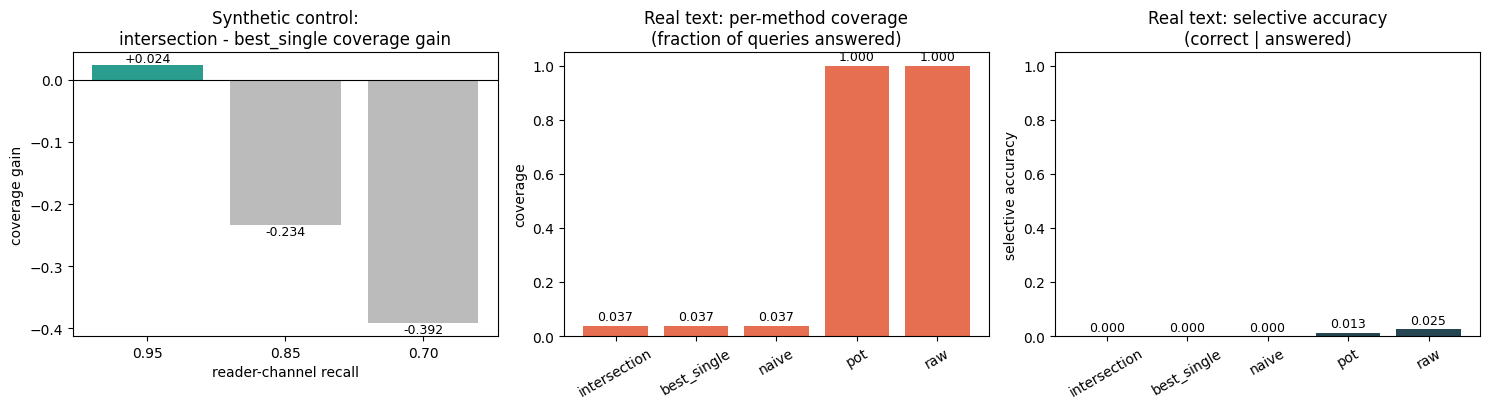

saved demo_results.png


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) synthetic control: coverage gain vs recall
rs = [r for r in SYNTH_RECALLS]
gains = [synth[f"recall_{int(r*100)}"]["coverage_gain_intersection_vs_best"] for r in rs]
colors = ["#2a9d8f" if g > 0 else "#bbbbbb" for g in gains]
ax[0].bar([f"{r:.2f}" for r in rs], gains, color=colors)
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_title("Synthetic control:\nintersection - best_single coverage gain")
ax[0].set_xlabel("reader-channel recall"); ax[0].set_ylabel("coverage gain")
for i, g in enumerate(gains):
    ax[0].text(i, g, f"{g:+.3f}", ha="center",
               va="bottom" if g >= 0 else "top", fontsize=9)

# (2) real-text per-method coverage
ms = list(METHODS.keys())
covs = [per_method_cov[m] for m in ms]
ax[1].bar(ms, covs, color="#e76f51")
ax[1].set_title("Real text: per-method coverage\n(fraction of queries answered)")
ax[1].set_ylabel("coverage"); ax[1].set_ylim(0, 1.05)
ax[1].tick_params(axis="x", rotation=30)
for i, c in enumerate(covs):
    ax[1].text(i, c + 0.02, f"{c:.3f}", ha="center", fontsize=9)

# (3) real-text selective accuracy
accs = []
for m in ms:
    _, _, a = _curve(recs[m])
    accs.append(a if a == a else 0.0)
ax[2].bar(ms, accs, color="#264653")
ax[2].set_title("Real text: selective accuracy\n(correct | answered)")
ax[2].set_ylabel("selective accuracy"); ax[2].set_ylim(0, 1.05)
ax[2].tick_params(axis="x", rotation=30)
for i, a in enumerate(accs):
    ax[2].text(i, a + 0.02, f"{a:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("demo_results.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved demo_results.png")

## Summary

| claim | demo result |
|---|---|
| a-priori gate structure exists in gold | **GO**, TDDMan N=125 (NarrativeTime 0, MATRES 0) |
| synthetic positive control (recall 0.95) | intersection **> best-single** → mechanism is detectable |
| real-text cross-path intersection vs best-single | gap **0.0**, CI brackets point, Holm n.s. |
| realized intersection bite on real text | **0** for every query |
| forced single-tight `raw` read | tight but only **~3%** correct (unsound) |

**Scope-boundary conclusion:** the richer Allen algebra that *enables* intersection bite (gate
GO + synthetic control) is exactly the one LLMs **cannot read informatively** from text — reads
are near-universe/underdetermined, so the composition stays at the universe and the mechanism
cannot realize. What survives the negative: the inherited **exact-table Allen composition** and
the gold-free **abstain-on-collapse certificate** (the intersection of sound read sets is always
sound). The multi-path-richer **RCC-8 spatial** corpus is the recommended real-text venue for
iter-5.